# Tugas 7 | Analisis PageRank Dataset uts_berita

1. Graph hubungan antar berita
2. Visualisasi graf
3. 5 berita dengan PageRank tertinggi

### import library

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Baca dataset berita
df_berita = pd.read_csv("uts_berita.csv")
df_berita


,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
...,...,...,...,...,...,...
1495,1496,Laporan Sebab Tabrakan Pesawat-Black Hawk Dita...,Anggota Dewan Keselamatan Transportasi Nasiona...,"Jumat, 31 Jan 2025 04:40 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1496,1497,"Israel Bebaskan 110 Sandera Palestina, Diantar...",Israel telah membebaskan 110 tahanan Palestina...,"Jumat, 31 Jan 2025 03:01 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1497,1498,Hamas Konfirmasi Kematian Komandan Al Qassam M...,Hamas mengonfirmasi kematian kepala militernya...,"Jumat, 31 Jan 2025 02:30 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...
1498,1499,Black Box American Airlines Ditemukan Usai Tab...,Tim penyelam diduga menemukan satu dari dua bl...,"Jumat, 31 Jan 2025 01:00 WIB",Internasional,https://www.cnnindonesia.com/internasional/202...


In [3]:
# pakai kolom yang sudah di procesing sebelumnya yaitu 'clean_berita'
if 'clean_berita' not in df_berita.columns:
    df_berita['clean_berita'] = df_berita['berita']

In [4]:
# Ubah teks berita ke vektor TF-IDF
vectorizer_berita = TfidfVectorizer(max_df=0.9, min_df=2)
X_berita = vectorizer_berita.fit_transform(df_berita['clean_berita'])

In [5]:
# Hitung kemiripan antar berita (cosine similarity)
sim_berita = cosine_similarity(X_berita)

In [6]:
# Buat graph berdasarkan threshold similarity (misal > 0.3)
G_berita = nx.Graph()
for i in range(len(sim_berita)):
    for j in range(i + 1, len(sim_berita)):
        if sim_berita[i, j] > 0.3:
            G_berita.add_edge(i, j, weight=sim_berita[i, j])

print(f"Jumlah Node (berita): {G_berita.number_of_nodes()}")
print(f"Jumlah Edge (berita): {G_berita.number_of_edges()}")

Jumlah Node (berita): 1276
Jumlah Edge (berita): 9389


In [7]:
# Hitung PageRank berita
pagerank_berita = nx.pagerank(G_berita)
sorted_pr_berita = sorted(pagerank_berita.items(), key=lambda x: x[1], reverse=True)

print("\n5 Berita dengan PageRank tertinggi:")
for idx, score in sorted_pr_berita[:5]:
    judul = df_berita.iloc[idx].get('judul', '[tidak ada judul]')
    print(f"Berita #{idx} ({judul}): {score}")


5 Berita dengan PageRank tertinggi:
Berita #543 (Timnas Indonesia Pasca-STY: Garang atau Garing?): 0.001992447544093504
Berita #935 (Makan Gizi Gratis Solo Dimulai Pekan Depan, Pemkot Belum Dikoordinasi): 0.0017302430106725893
Berita #551 (Media Korea Sorot Beda Nasib STY dan Kim Sang Sik usai Piala AFF 2024): 0.0016830911684315808
Berita #607 (Pantau Timnas Indonesia U-20, Kluivert Diskusi dengan Indra Sjafri): 0.0016811289398406422
Berita #439 (Klasemen Grup B Piala AFF 2024: Timnas Indonesia Harap-harap Cemas): 0.0016406718536894618


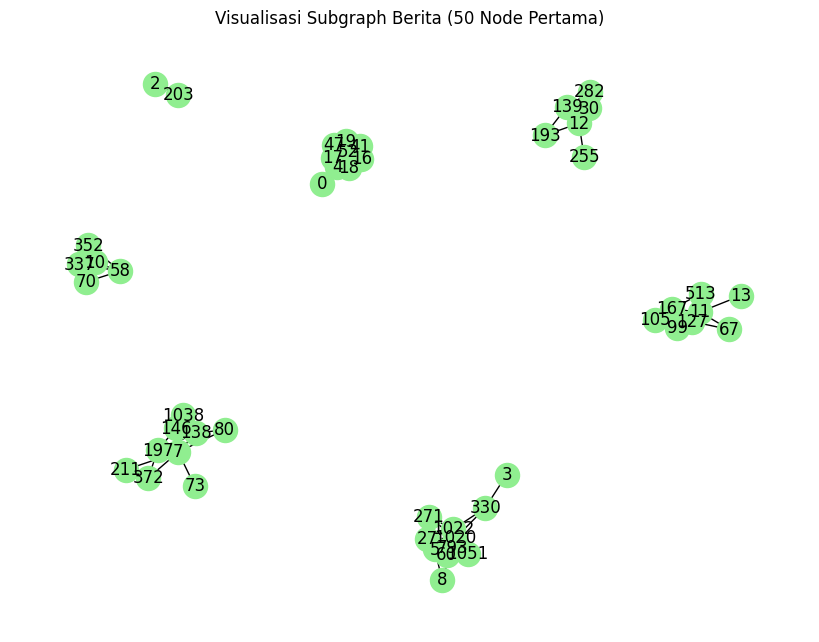

In [8]:
# Visualisasi graph berita (ambil subset kecil)
plt.figure(figsize=(8,6))
sub_berita = list(G_berita.nodes)[:50]
nx.draw(G_berita.subgraph(sub_berita), node_color='lightgreen', with_labels=True)
plt.title("Visualisasi Subgraph Berita (50 Node Pertama)")
plt.show()